# This file is used to analysis other smoothing modes

In [2]:
import pandas as pd
import numpy as np
import os
import sys
from sklearn.metrics import mean_squared_error
import json

In [3]:
DATASET_MAX_N_OBS = {
    'autompg': 400,
    'breastcancer': 200,
    'fertility': 100,  # Small dataset
    'forest': 500,
    'housing': 500,
    'pendulum': 500,
    'qsar_aquatic_toxicity': 500,
    'servo': 100,      # Small dataset
    'stock': 500,
    'yacht_hydrodynamics': 300 , # Medium dataset
    'ENB2012_data_energy_heating': 768,
    'ENB2012_data_energy_cooling': 768,
    'real_estate': 414,
    'winequality-red': 1599,
    'winequality-white': 4898,
    'airfoil_self_noise': 1503,
    'qsar_fish_toxicity': 908,
    'Combined_Cycle_Power_Plant': 9568,
}

def get_valid_n_obs_list(data_name, requested_n_obs_list):
    """
    Filter n_obs_list based on dataset's maximum available samples
    
    Args:
        data_name: Name of the dataset
        requested_n_obs_list: List of requested sample sizes
        
    Returns:
        Filtered list of valid sample sizes
    """
    max_n_obs = DATASET_MAX_N_OBS.get(data_name, 500)
    valid_list = [n for n in requested_n_obs_list if n <= max_n_obs]
    
    return valid_list

# List of datasets (same as in experiment)
data_names = [
    'fertility', 
    'forest',
    'qsar_aquatic_toxicity', 
    'stock', 
    'yacht_hydrodynamics',
    'real_estate',
    'winequality-red',
    'winequality-white',
    'qsar_fish_toxicity',
    'Combined_Cycle_Power_Plant'
]


In [4]:
def calculate_mse_metrics(data_name, n_obs_list_full = [50,100,200,300,400,500], 
                            results_dir='../results', metrics_dir='./metrics'):
    """
    Calculate MSE for all models across different sample sizes and replications
    
    Args:
        data_name: Dataset name (e.g., 'autompg')
        n_obs_list: List of sample sizes to analyze
        save: Whether to save results to CSV
        results_dir: Directory containing experiment results
        metrics_dir: Directory to save metrics (if None, won't save even if save=True)
    
    Returns:
        DataFrame with columns: data, n_obs, r, base_rf, rf10, rf100, srf_normal_*, srf_hypsec_*
    """
    n_obs_list = get_valid_n_obs_list(data_name, n_obs_list_full)
    # List to store results
    results_list = []
    
    # Define all model names (use original names for reading)
    srf_model_names = ['srf_normal_global_pred','srf_hypsec_global_pred','srf_normal_per_dim_pred',
                        'srf_hypsec_per_dim_pred','srf_normal_per_tree_pred','srf_hypsec_per_tree_pred']
    
    # Iterate through all sample sizes and replications
    for n_obs in n_obs_list:
        for r in range(100):  # 100 replications
            srf_pred_file = f'{results_dir}/{data_name}/other_mode_predictions_noCV/{data_name}_n{n_obs}_r{r}.csv'
            
            # Check if file exists
            if not os.path.exists(srf_pred_file):
                continue

                # Load predictions
            
            srf_pred_df = pd.read_csv(srf_pred_file)
            y_test = srf_pred_df['y_test'].values
            
            # Create result dictionary for this replication
            result = {
                'data': data_name,
                'n_obs': n_obs,
                'r': r
            }
            
            # Calculate MSE for each model
            for srf_model in srf_model_names:
                pred_col = f'{srf_model}'
                
                if pred_col in srf_pred_df.columns:
                    y_pred = srf_pred_df[pred_col].values
                    
                    # Check for NaN values
                    if np.any(np.isnan(y_pred)):
                        result[srf_model] = np.nan
                    else:
                        result[srf_model] = mean_squared_error(y_test, y_pred)
                else:
                    result[srf_model] = np.nan
                    
            
            results_list.append(result)
                

    
    # Create DataFrame
    results_df = pd.DataFrame(results_list)
    
    # Reorder columns
    cols_order = ['data', 'n_obs', 'r'] + srf_model_names
    results_df = results_df[cols_order]
    results_df.rename(columns={
        'data':'Data',
        'srf_normal_global_pred':'SRFSTEnorm',
        'srf_hypsec_global_pred':'SRFSTEhyp',
        'srf_normal_per_dim_pred':'SRFSTEPDnorm',
        'srf_hypsec_per_dim_pred':'SRFSTEPDhyp',
        'srf_normal_per_tree_pred':'SRFESTnorm',
        'srf_hypsec_per_tree_pred':'SRFESThyp'
      }, inplace=True)
    
    # Save if requested and metrics_dir is not None
    if metrics_dir is not None:
        save_path = f'{metrics_dir}/{data_name}/{data_name}_other_mode_mse.csv'
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        results_df.to_csv(save_path, index=False)
        print(f"Saved metrics to: {save_path}")
    
    else:
        return results_df

In [7]:
for data in data_names:
    calculate_mse_metrics(data_name=data,metrics_dir= './metrics')

Saved metrics to: ./metrics/fertility/fertility_other_mode_mse.csv
Saved metrics to: ./metrics/forest/forest_other_mode_mse.csv
Saved metrics to: ./metrics/qsar_aquatic_toxicity/qsar_aquatic_toxicity_other_mode_mse.csv
Saved metrics to: ./metrics/stock/stock_other_mode_mse.csv
Saved metrics to: ./metrics/yacht_hydrodynamics/yacht_hydrodynamics_other_mode_mse.csv
Saved metrics to: ./metrics/real_estate/real_estate_other_mode_mse.csv
Saved metrics to: ./metrics/winequality-red/winequality-red_other_mode_mse.csv
Saved metrics to: ./metrics/winequality-white/winequality-white_other_mode_mse.csv
Saved metrics to: ./metrics/qsar_fish_toxicity/qsar_fish_toxicity_other_mode_mse.csv
Saved metrics to: ./metrics/Combined_Cycle_Power_Plant/Combined_Cycle_Power_Plant_other_mode_mse.csv


In [5]:
def combine_all_data_metrics(metric,data_list,metrics_path,save_path=None):
    metric_df = pd.DataFrame()
    for data_name in data_list:
        metric_df = pd.concat([metric_df,pd.read_csv(f'{metrics_path}/{data_name}/{data_name}_other_mode_{metric}.csv')])

    if save_path is not None:
        metric_df.to_csv(f'{save_path}/other_mode_{metric}_combined_all_data.csv',index=False)
    else:
        return metric_df

In [10]:
combine_all_data_metrics(metric='mse',data_list=data_names,
                                        metrics_path= './metrics',
                                        save_path= './metrics')

In [13]:
paper_model_mse = pd.read_csv('./metrics/mse_combined_all_data.csv')

In [11]:
other_mode_mse = pd.read_csv('./metrics/other_mode_mse_combined_all_data.csv')

In [18]:
combined_all_model_mse = pd.merge(paper_model_mse,other_mode_mse,on=['Data','n_obs','r'],how='left')

In [20]:
combined_all_model_mse.to_csv('./metrics/all_models_mse.csv',index=False)

# Get Percentage Improvement over RF(10)

In [8]:
combined_all_model_mse = pd.read_csv('./metrics/all_models_mse.csv')

In [9]:
combined_all_model_mse.columns

Index(['Data', 'n_obs', 'r', 'RF(10)', 'RF(20)', 'RF(50)', 'RF(100)', 'GP',
       'SRF_EST_PD(Norm)', 'SRF_EST_PD(Hypsec)', 'SRFSTEnorm', 'SRFSTEhyp',
       'SRFSTEPDnorm', 'SRFSTEPDhyp', 'SRFESTnorm', 'SRFESThyp'],
      dtype='object')

In [10]:
def calculate_percentage(df):
    pi_df = pd.DataFrame()
    pi_df['Data'] = df['Data']
    pi_df['N'] = df['N']
    pi_df['P'] = df['P']
    pi_df['n'] = df['n']
    pi_df['r'] = df['r']
    
    pi_df['RF(20)'] = round((df['RF(10)'] - df['RF(20)'])/df['RF(10)']*100,4)
    pi_df['RF(50)'] = round((df['RF(10)'] - df['RF(50)'])/df['RF(10)']*100,4)
    pi_df['RF(100)'] = round((df['RF(10)'] - df['RF(100)'])/df['RF(10)']*100,4)
    pi_df['GP'] = round((df['RF(10)'] - df['GP'])/df['RF(10)']*100,4)

    pi_df['SRF_EST_PD(Norm)'] = round((df['RF(10)'] - df['SRF_EST_PD(Norm)'])/df['RF(10)']*100,4)
    pi_df['SRF_EST_PD(Hypsec)'] = round((df['RF(10)'] - df['SRF_EST_PD(Hypsec)'])/df['RF(10)']*100,4)
    pi_df['SRFSTEnorm'] = round((df['RF(10)'] - df['SRFSTEnorm'])/df['RF(10)']*100,4)
    pi_df['SRFSTEhyp'] = round((df['RF(10)'] - df['SRFSTEhyp'])/df['RF(10)']*100,4)
    pi_df['SRFSTEPDnorm'] = round((df['RF(10)'] - df['SRFSTEPDnorm'])/df['RF(10)']*100,4)
    pi_df['SRFSTEPDhyp'] = round((df['RF(10)'] - df['SRFSTEPDhyp'])/df['RF(10)']*100,4)
    pi_df['SRFESTnorm'] = round((df['RF(10)'] - df['SRFESTnorm'])/df['RF(10)']*100,4)
    pi_df['SRFESThyp'] = round((df['RF(10)'] - df['SRFESThyp'])/df['RF(10)']*100,4)


    return pi_df

In [11]:
def add_data_info(data_names):
    data_info = pd.DataFrame()
    p_list = []
    n_list = []
    for data_name in data_names:
        data = pd.read_csv(f'../../data/{data_name}.csv')
        p_list.append(data.shape[1]-1)
        n_list.append(data.shape[0])
    data_info['Data'] = data_names
    data_info['P'] = p_list
    data_info['N'] = n_list
    return data_info

In [12]:
data_info = add_data_info(data_names)

In [13]:
# combine data_info with best_model_pi
combined_mse_df = pd.merge(combined_all_model_mse, data_info, on='Data', how='left')
# rename n to n_obs
combined_mse_df = combined_mse_df.rename(columns={'n_obs':'n'})
# order the columns
combined_mse_df = combined_mse_df[['Data','N','P','n','r','RF(10)','RF(20)','RF(50)',
                                    'RF(100)','GP','SRF_EST_PD(Norm)','SRF_EST_PD(Hypsec)',
                                    'SRFSTEnorm','SRFSTEhyp','SRFSTEPDnorm','SRFSTEPDhyp',
                                    'SRFESTnorm','SRFESThyp']]

In [14]:
combined_mse_df

,Data,N,P,n,r,RF(10),RF(20),RF(50),RF(100),GP,SRF_EST_PD(Norm),SRF_EST_PD(Hypsec),SRFSTEnorm,SRFSTEhyp,SRFSTEPDnorm,SRFSTEPDhyp,SRFESTnorm,SRFESThyp
0,fertility,100,9,50,0,0.044909,0.045380,0.046300,0.043865,0.038578,0.035588,0.035576,0.035766,0.035777,0.037643,0.037920,0.036933,0.037030
1,fertility,100,9,50,1,0.039270,0.035568,0.034324,0.035136,0.041738,0.035319,0.035108,0.035599,0.035676,0.039817,0.039715,0.038952,0.039426
2,fertility,100,9,50,2,0.041473,0.039620,0.041042,0.039670,0.046084,0.036816,0.036961,0.042519,0.042494,0.042661,0.042729,0.041948,0.042164
3,fertility,100,9,50,3,0.039350,0.042345,0.039342,0.039329,0.039149,0.036053,0.035912,0.036937,0.037033,0.039370,0.039308,0.039525,0.039414
4,fertility,100,9,50,4,0.038044,0.035255,0.034489,0.034218,0.035312,0.033262,0.032896,0.034679,0.033351,0.034987,0.035055,0.034755,0.034808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5295,Combined_Cycle_Power_Plant,9568,4,500,95,21.063966,20.376660,19.516723,19.339205,37.421178,18.319585,18.117337,18.090034,18.117570,18.233121,18.170755,18.447934,18.254978
5296,Combined_Cycle_Power_Plant,9568,4,500,96,21.337937,21.012749,20.129322,19.987684,38.040156,18.658859,18.695136,18.630347,18.625425,18.761443,18.711077,18.772135,18.672772
5297,Combined_Cycle_Power_Plant,9568,4,500,97,20.499778,19.931488,19.316219,19.063135,32.104660,18.447254,18.305758,18.640099,18.574030,18.654824,18.539275,18.404189,18.279483
5298,Combined_Cycle_Power_Plant,9568,4,500,98,20.167187,19.498746,19.099909,19.036338,38.708539,18.633770,18.567238,18.611122,18.568820,18.567829,18.505421,18.699795,18.458147


In [15]:
data_name_mapping = {
    'Combined_Cycle_Power_Plant': 'CCPP',
    'qsar_fish_toxicity': 'Qsar Fish Toxicity',
    'real_estate': 'Real Estate',
    'yacht_hydrodynamics': 'Yacht Hydrodynamics',
    'qsar_aquatic_toxicity': 'Qsar Aquatic Toxicity',
    'fertility': 'Fertility',
    'stock': 'Stock',
    'winequality-red': 'Winequality (Red)',
    'winequality-white': 'Winequality (White)',
    'forest': 'Forest'
}
combined_mse_df['Data'] = combined_mse_df['Data'].replace(data_name_mapping)

In [16]:
pi_df = calculate_percentage(combined_mse_df)

In [32]:
pi_df.to_csv('./metrics/all_models_combined_PI.csv',index=False)

In [4]:
pi_df = pd.read_csv('./metrics/all_models_combined_PI.csv')

In [5]:
PIMSE_mean = pi_df.groupby(['Data','N','P']).mean().drop(columns=['r','n']).reset_index()
PIMSE_std = pi_df.groupby(['Data','N','P']).std().drop(columns=['r','n']).reset_index()
pi_df['cases'] = 1
cased_by_n_obs = pi_df.groupby(['Data']).sum().reset_index()
PIMSE_std['cases'] = cased_by_n_obs['cases']

mean_mse_95CI = pd.DataFrame()
mean_mse_95CI['Data'] = PIMSE_mean['Data']
mean_mse_95CI['N'] = PIMSE_mean['N']
mean_mse_95CI['P'] = PIMSE_mean['P']

mean_mse_95CI['RF(20)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['RF(20)'], PIMSE_std['RF(20)']/np.sqrt(PIMSE_std['cases']))]
mean_mse_95CI['RF(50)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['RF(50)'], PIMSE_std['RF(50)']/np.sqrt(PIMSE_std['cases']))]
mean_mse_95CI['RF(100)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['RF(100)'], PIMSE_std['RF(100)']/np.sqrt(PIMSE_std['cases']))]
mean_mse_95CI['GP'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['GP'], PIMSE_std['GP']/np.sqrt(PIMSE_std['cases']))]
mean_mse_95CI['EST-PD(Norm)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['SRF_EST_PD(Norm)'], PIMSE_std['SRF_EST_PD(Norm)']/np.sqrt(PIMSE_std['cases']))]
mean_mse_95CI['EST-PD(Hypsec)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['SRF_EST_PD(Hypsec)'], PIMSE_std['SRF_EST_PD(Hypsec)']/np.sqrt(PIMSE_std['cases']))]

mean_mse_95CI['STE(Norm)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['SRFSTEnorm'], PIMSE_std['SRFSTEnorm']/np.sqrt(PIMSE_std['cases']))]
mean_mse_95CI['STE(Hypsec)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['SRFSTEhyp'], PIMSE_std['SRFSTEhyp']/np.sqrt(PIMSE_std['cases']))]
mean_mse_95CI['STE-PD(Norm)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['SRFSTEPDnorm'], PIMSE_std['SRFSTEPDnorm']/np.sqrt(PIMSE_std['cases']))]
mean_mse_95CI['STE-PD(Hypsec)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['SRFSTEPDhyp'], PIMSE_std['SRFSTEPDhyp']/np.sqrt(PIMSE_std['cases']))]
mean_mse_95CI['EST(Norm)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['SRFESTnorm'], PIMSE_std['SRFESTnorm']/np.sqrt(PIMSE_std['cases']))]
mean_mse_95CI['EST(Hypsec)'] = [f"{m:.2f} ({s:.2f})" for m, s in zip(PIMSE_mean['SRFESThyp'], PIMSE_std['SRFESThyp']/np.sqrt(PIMSE_std['cases']))]

mean_best_model_pi = mean_mse_95CI.sort_values(by='P',ascending=True)

In [6]:
mean_best_model_pi

,Data,N,P,RF(20),RF(50),RF(100),GP,EST-PD(Norm),EST-PD(Hypsec),STE(Norm),STE(Hypsec),STE-PD(Norm),STE-PD(Hypsec),EST(Norm),EST(Hypsec)
0,CCPP,9568,4,4.40 (0.16),6.89 (0.18),7.62 (0.19),-76.48 (4.10),12.39 (0.15),12.88 (0.16),12.98 (0.21),13.17 (0.20),12.30 (0.19),12.89 (0.19),11.34 (0.16),12.83 (0.16)
4,Qsar Fish Toxicity,908,6,3.47 (0.14),5.62 (0.17),6.25 (0.17),-19.49 (0.73),8.04 (0.18),8.00 (0.18),5.66 (0.23),5.79 (0.22),2.81 (0.31),-0.16 (0.36),6.30 (0.25),4.73 (0.28)
5,Real Estate,414,6,3.69 (0.27),6.17 (0.33),6.83 (0.34),-100.77 (1.75),2.99 (0.42),3.22 (0.42),-11.38 (1.02),-13.14 (1.06),-22.15 (1.00),-23.86 (1.01),-28.39 (1.12),-28.18 (1.11)
9,Yacht Hydrodynamics,308,6,16.29 (1.38),29.94 (1.27),33.22 (1.21),-284.56 (14.84),26.60 (0.90),26.05 (0.91),1.60 (1.24),1.70 (1.18),24.65 (0.96),25.15 (1.01),-185.57 (9.83),-319.36 (16.36)
3,Qsar Aquatic Toxicity,537,8,4.27 (0.18),6.28 (0.21),6.94 (0.22),-47.49 (1.41),6.72 (0.20),6.65 (0.20),4.64 (0.27),4.86 (0.27),2.25 (0.35),0.02 (0.39),5.28 (0.29),4.29 (0.31)
1,Fertility,100,9,0.91 (0.51),2.38 (0.64),3.19 (0.62),-1.24 (1.34),12.94 (0.72),13.08 (0.73),9.59 (0.90),9.61 (0.89),3.66 (1.31),3.18 (1.32),5.98 (1.23),5.40 (1.26)
6,Stock,536,11,8.48 (0.22),11.20 (0.25),12.03 (0.25),-422.89 (5.17),16.22 (0.30),16.14 (0.30),-409.94 (5.05),-413.99 (5.06),-410.50 (4.99),-413.99 (5.06),-369.06 (4.30),-386.94 (4.56)
7,Winequality (Red),1599,11,3.75 (0.11),5.78 (0.15),6.51 (0.16),-24.66 (0.39),7.49 (0.19),7.54 (0.19),1.27 (0.27),1.47 (0.27),-8.57 (0.40),-11.23 (0.42),-3.29 (0.35),-5.16 (0.37)
8,Winequality (White),4898,11,3.98 (0.10),6.32 (0.12),7.11 (0.13),-17.85 (0.36),7.23 (0.16),7.19 (0.16),0.29 (0.30),0.64 (0.29),-7.80 (0.39),-9.10 (0.40),-5.48 (0.36),-6.45 (0.37)
2,Forest,517,12,2.96 (0.16),4.81 (0.18),5.51 (0.18),18.98 (0.28),15.59 (0.21),15.45 (0.21),17.94 (0.24),17.90 (0.24),17.85 (0.23),18.14 (0.24),17.54 (0.23),17.70 (0.23)


In [7]:
appendix_table = mean_best_model_pi[['Data','P','EST-PD(Norm)','EST-PD(Hypsec)','STE(Norm)','STE(Hypsec)','STE-PD(Norm)','STE-PD(Hypsec)','EST(Norm)','EST(Hypsec)']]

In [9]:
appendix_table.to_csv('./metrics/appendix_table_four_SRF_modes.csv',index=False)

In [8]:
appendix_table

,Data,P,EST-PD(Norm),EST-PD(Hypsec),STE(Norm),STE(Hypsec),STE-PD(Norm),STE-PD(Hypsec),EST(Norm),EST(Hypsec)
0,CCPP,4,12.39 (0.15),12.88 (0.16),12.98 (0.21),13.17 (0.20),12.30 (0.19),12.89 (0.19),11.34 (0.16),12.83 (0.16)
4,Qsar Fish Toxicity,6,8.04 (0.18),8.00 (0.18),5.66 (0.23),5.79 (0.22),2.81 (0.31),-0.16 (0.36),6.30 (0.25),4.73 (0.28)
5,Real Estate,6,2.99 (0.42),3.22 (0.42),-11.38 (1.02),-13.14 (1.06),-22.15 (1.00),-23.86 (1.01),-28.39 (1.12),-28.18 (1.11)
9,Yacht Hydrodynamics,6,26.60 (0.90),26.05 (0.91),1.60 (1.24),1.70 (1.18),24.65 (0.96),25.15 (1.01),-185.57 (9.83),-319.36 (16.36)
3,Qsar Aquatic Toxicity,8,6.72 (0.20),6.65 (0.20),4.64 (0.27),4.86 (0.27),2.25 (0.35),0.02 (0.39),5.28 (0.29),4.29 (0.31)
1,Fertility,9,12.94 (0.72),13.08 (0.73),9.59 (0.90),9.61 (0.89),3.66 (1.31),3.18 (1.32),5.98 (1.23),5.40 (1.26)
6,Stock,11,16.22 (0.30),16.14 (0.30),-409.94 (5.05),-413.99 (5.06),-410.50 (4.99),-413.99 (5.06),-369.06 (4.30),-386.94 (4.56)
7,Winequality (Red),11,7.49 (0.19),7.54 (0.19),1.27 (0.27),1.47 (0.27),-8.57 (0.40),-11.23 (0.42),-3.29 (0.35),-5.16 (0.37)
8,Winequality (White),11,7.23 (0.16),7.19 (0.16),0.29 (0.30),0.64 (0.29),-7.80 (0.39),-9.10 (0.40),-5.48 (0.36),-6.45 (0.37)
2,Forest,12,15.59 (0.21),15.45 (0.21),17.94 (0.24),17.90 (0.24),17.85 (0.23),18.14 (0.24),17.54 (0.23),17.70 (0.23)


In [36]:
stats_df = pi_df.drop(columns=['Data','N','n','P','r','cases'])

In [37]:
stats_df

,RF(20),RF(50),RF(100),GP,SRF_EST_PD(Norm),SRF_EST_PD(Hypsec),SRFSTEnorm,SRFSTEhyp,SRFSTEPDnorm,SRFSTEPDhyp,SRFESTnorm,SRFESThyp
0,-1.0494,-3.0970,2.3248,14.0984,20.7553,20.7815,20.3592,20.3334,16.1788,15.5629,17.7602,17.5438
1,9.4287,12.5960,10.5270,-6.2826,10.0622,10.6005,9.3482,9.1539,-1.3925,-1.1329,0.8103,-0.3971
2,4.4689,1.0398,4.3473,-11.1183,11.2289,10.8808,-2.5218,-2.4598,-2.8645,-3.0278,-1.1442,-1.6663
3,-7.6097,0.0202,0.0534,0.5117,8.3785,8.7366,6.1320,5.8895,-0.0506,0.1075,-0.4454,-0.1630
4,7.3313,9.3448,10.0583,7.1815,12.5709,13.5310,8.8462,12.3354,8.0360,7.8583,8.6464,8.5053
...,...,...,...,...,...,...,...,...,...,...,...,...
5295,3.2629,7.3455,8.1882,-77.6549,13.0288,13.9890,14.1186,13.9879,13.4393,13.7354,12.4195,13.3355
5296,1.5240,5.6642,6.3279,-78.2748,12.5555,12.3855,12.6891,12.7122,12.0747,12.3108,12.0246,12.4903
5297,2.7722,5.7735,7.0081,-56.6098,10.0124,10.7027,9.0717,9.3940,8.9999,9.5635,10.2225,10.8308
5298,3.3145,5.2921,5.6074,-91.9382,7.6035,7.9334,7.7158,7.9256,7.9305,8.2399,7.2761,8.4744


In [38]:
from autorank import autorank, plot_stats, create_report, latex_table

In [39]:
result = autorank(stats_df, alpha=0.05, verbose=True, order='descending')

/opt/homebrew/Caskroom/miniforge/base/envs/my_research_env/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5300.
  res = hypotest_fun_out(*samples, **kwds)


Rejecting null hypothesis that data is normal for column RF(20) (p=0.000000<0.004167)
Rejecting null hypothesis that data is normal for column RF(50) (p=0.000000<0.004167)
Rejecting null hypothesis that data is normal for column RF(100) (p=0.000000<0.004167)
Rejecting null hypothesis that data is normal for column GP (p=0.000000<0.004167)
Rejecting null hypothesis that data is normal for column SRF_EST_PD(Norm) (p=0.000000<0.004167)
Rejecting null hypothesis that data is normal for column SRF_EST_PD(Hypsec) (p=0.000000<0.004167)
Rejecting null hypothesis that data is normal for column SRFSTEnorm (p=0.000000<0.004167)
Rejecting null hypothesis that data is normal for column SRFSTEhyp (p=0.000000<0.004167)
Rejecting null hypothesis that data is normal for column SRFSTEPDnorm (p=0.000000<0.004167)
Rejecting null hypothesis that data is normal for column SRFSTEPDhyp (p=0.000000<0.004167)
Rejecting null hypothesis that data is normal for column SRFESTnorm (p=0.000000<0.004167)
Rejecting nul

<Axes: >

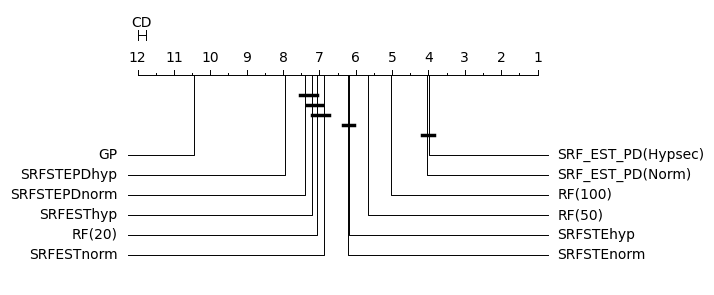

In [40]:
plot_stats(result)